# Master Comparison — All 5 SCM Estimators
## Base SCM · ASCM · EN-SCM · MC-SCM · SDID

**Purpose:**
This notebook re-runs every estimator from scratch in a single execution context,
then produces a unified comparison across all five methods. Run this AFTER validating
each individual method notebook.

**Estimators compared:**

| # | Method | Core Innovation |
|---|--------|----------------|
| 0 | **Base SCM** | Constrained weights, CAPE as donor |
| 1 | **ASCM** | Ridge bias-correction on SCM residuals |
| 2 | **EN-SCM** | Elastic net (L1+L2) regularised weights |
| 3 | **MC-SCM** | Nuclear norm matrix completion (no donor weights) |
| 4 | **SDID** | Unit weights + time weights, jackknife SE |

**Output:** unified metrics table, overlaid counterfactual plot, ratio comparison bar,
cumulative effect distribution, and a method agreement heatmap.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & plotting config
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 10,
})

METHOD_COLORS = {
    'Base SCM': '#aaaaaa',
    'ASCM':     '#e94560',
    'EN-SCM':   '#f39c12',
    'MC-SCM':   '#2ecc71',
    'SDID':     '#0f3460',
}
METHOD_LS = {
    'Base SCM': ':',
    'ASCM':     '--',
    'EN-SCM':   '-.',
    'MC-SCM':   (0,(3,1,1,1)),
    'SDID':     '-',
}

print("Master comparison notebook ready.")
print(f"Methods: {list(METHOD_COLORS.keys())}")


Master comparison notebook ready.
Methods: ['Base SCM', 'ASCM', 'EN-SCM', 'MC-SCM', 'SDID']


## Shared Setup — All Estimators Run Here

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Data loading (shared across all methods)
# ═══════════════════════════════════════════════════════════════════════════════

CSV_PATH = '../data/corridor.csv'

df = pd.read_csv(CSV_PATH)
df['Date']        = df['Date'].astype(str).str.strip()
df['Corridor']    = df['Corridor'].astype(str).str.strip()
df['Date_period'] = pd.PeriodIndex(df['Date'], freq='M')

Y_COL       = 'Rail_Vol_mt'
TREATED     = 'NATCOR'
TREAT_START = pd.Period('2022-04', freq='M')
PRE_END     = TREAT_START - 1

wide     = df.pivot(index='Date_period', columns='Corridor', values=Y_COL).sort_index()
donors   = [c for c in wide.columns if c != TREATED]
pre_idx  = wide.index[wide.index <= PRE_END]
post_idx = wide.index[wide.index >= TREAT_START]
T_pre    = len(pre_idx)
T_post   = len(post_idx)
T_total  = len(wide)
t_stamps = wide.index.to_timestamp()
treat_t  = TREAT_START.to_timestamp()

Y_all   = wide[TREATED].values
X_all   = wide[donors[0]].values
Y_pre_v = wide.loc[pre_idx,  TREATED].values
Y_post_v= wide.loc[post_idx, TREATED].values
X_pre_v = wide.loc[pre_idx,  donors[0]].values
X_post_v= wide.loc[post_idx, donors[0]].values

nat_col  = list(wide.columns).index(TREATED)
Y_mat    = wide.values.astype(float)

def rmspe(a, b): return np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2))
def mape(a, b):
    a = np.asarray(a)
    return np.mean(np.abs((a - b) / np.where(a==0, 1e-10, a))) * 100

print(f"Data loaded: {T_total} periods, {T_pre} pre, {T_post} post")
print(f"Corridors: {list(wide.columns)}")


Data loaded: 120 periods, 87 pre, 33 post
Corridors: ['CAPE', 'NATCOR']


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Method 0: Base SCM
# ═══════════════════════════════════════════════════════════════════════════════

def fit_scm(Y_pre, X_pre):
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1,1)
    n = X_pre.shape[1]
    res = minimize(lambda w: np.sum((Y_pre - X_pre @ w)**2),
                   np.ones(n)/n, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-12,'maxiter':5000})
    return np.clip(res.x, 0, None)

w_scm  = fit_scm(Y_pre_v, X_pre_v.reshape(-1,1))
cf_scm = X_all * w_scm[0]
gap_scm = Y_all - cf_scm

results = {}
results['Base SCM'] = {
    'cf':       cf_scm,
    'gap':      gap_scm,
    'pre_r':    rmspe(Y_all[:T_pre], cf_scm[:T_pre]),
    'post_r':   rmspe(Y_all[T_pre:], cf_scm[T_pre:]),
    'cum':      gap_scm[T_pre:].sum(),
    'avg':      gap_scm[T_pre:].mean(),
    'mape':     mape(Y_all[T_pre:], cf_scm[T_pre:]),
    'method':   'Base SCM',
    'notes':    f'w_CAPE={w_scm[0]:.4f}',
}
r = results['Base SCM']
print(f"Base SCM  — Pre: {r['pre_r']:.4f}  Post: {r['post_r']:.4f}  "
      f"Ratio: {r['post_r']/r['pre_r']:.4f}  Cum: {r['cum']:.4f}")


Base SCM  — Pre: 0.2132  Post: 0.3653  Ratio: 1.7140  Cum: -11.1040


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Method 1: ASCM
# ═══════════════════════════════════════════════════════════════════════════════

def make_ridge_features(X_donor, t_idx, T_pre):
    t_norm = t_idx / T_pre
    return np.column_stack([X_donor, t_norm, t_norm**2, X_donor * t_norm])

t_pre_idx  = np.arange(T_pre)
t_all_idx  = np.arange(T_total)
feat_pre   = make_ridge_features(X_pre_v, t_pre_idx, T_pre)
feat_all   = make_ridge_features(X_all,   t_all_idx, T_pre)
res_pre    = Y_pre_v - cf_scm[:T_pre]

# Blocked CV for alpha
split = int(0.6 * T_pre)
alpha_grid = [1e-5,5e-5,1e-4,5e-4,1e-3,5e-3,0.01,0.05,0.1,0.5,1.0,5.0,10.0,50.0,100.0]
best_a, best_e = None, np.inf
for a in alpha_grid:
    r = Ridge(alpha=a, fit_intercept=True)
    r.fit(feat_pre[:split], res_pre[:split])
    e = rmspe(res_pre[split:], r.predict(feat_pre[split:]))
    if e < best_e: best_e, best_a = e, a

ridge_f = Ridge(alpha=best_a, fit_intercept=True)
ridge_f.fit(feat_pre, res_pre)
correction = ridge_f.predict(feat_all)
cf_ascm    = cf_scm + correction
gap_ascm   = Y_all - cf_ascm

results['ASCM'] = {
    'cf':    cf_ascm,
    'gap':   gap_ascm,
    'pre_r':  rmspe(Y_all[:T_pre], cf_ascm[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_ascm[T_pre:]),
    'cum':   gap_ascm[T_pre:].sum(),
    'avg':   gap_ascm[T_pre:].mean(),
    'mape':  mape(Y_all[T_pre:], cf_ascm[T_pre:]),
    'method':'ASCM',
    'notes': f'α={best_a}',
}
r = results['ASCM']
print(f"ASCM      — Pre: {r['pre_r']:.4f}  Post: {r['post_r']:.4f}  "
      f"Ratio: {r['post_r']/r['pre_r']:.4f}  Cum: {r['cum']:.4f}  (α={best_a})")


ASCM      — Pre: 0.0811  Post: 0.1324  Ratio: 1.6320  Cum: 3.6818  (α=0.05)


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Method 2: EN-SCM  (2-D CV)
# ═══════════════════════════════════════════════════════════════════════════════
import itertools

def fit_elastic_scm(Y_pre, X_pre, alpha=0.01, l1_ratio=0.5):
    if X_pre.ndim == 1: X_pre = X_pre.reshape(-1,1)
    n = X_pre.shape[1]
    def loss(w):
        r = Y_pre - X_pre @ w
        return np.mean(r**2) + alpha*l1_ratio*np.sum(np.abs(w)) + alpha*(1-l1_ratio)*0.5*np.sum(w**2)
    res = minimize(loss, np.ones(n)/n, method='SLSQP',
                   bounds=[(0,None)]*n, options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

alpha_g  = [1e-4,5e-4,1e-3,5e-3,0.01,0.05,0.1,0.5,1.0]
l1ratio_g = [0.0,0.1,0.25,0.5,0.75,0.9,1.0]
sp_en = int(0.6 * T_pre)
X_pre_2d = X_pre_v.reshape(-1,1)
best_a2, best_l2, best_e2 = None, None, np.inf
for a, l in itertools.product(alpha_g, l1ratio_g):
    w = fit_elastic_scm(Y_pre_v[:sp_en], X_pre_2d[:sp_en], alpha=a, l1_ratio=l)
    e = rmspe(Y_pre_v[sp_en:], X_pre_2d[sp_en:] @ w)
    if e < best_e2: best_e2, best_a2, best_l2 = e, a, l

w_en   = fit_elastic_scm(Y_pre_v, X_pre_2d, alpha=best_a2, l1_ratio=best_l2)
cf_en  = X_all * w_en[0]
gap_en = Y_all - cf_en

results['EN-SCM'] = {
    'cf':    cf_en,
    'gap':   gap_en,
    'pre_r':  rmspe(Y_all[:T_pre], cf_en[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_en[T_pre:]),
    'cum':   gap_en[T_pre:].sum(),
    'avg':   gap_en[T_pre:].mean(),
    'mape':  mape(Y_all[T_pre:], cf_en[T_pre:]),
    'method':'EN-SCM',
    'notes': f'α={best_a2},L1={best_l2}',
}
r = results['EN-SCM']
print(f"EN-SCM    — Pre: {r['pre_r']:.4f}  Post: {r['post_r']:.4f}  "
      f"Ratio: {r['post_r']/r['pre_r']:.4f}  Cum: {r['cum']:.4f}  (α={best_a2},L1={best_l2})")


EN-SCM    — Pre: 0.2097  Post: 0.0929  Ratio: 0.4430  Cum: -1.4575  (α=0.5,L1=0.0)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Method 3: MC-SCM  (SVT + blocked CV)
# ═══════════════════════════════════════════════════════════════════════════════

def svt(Y_obs, mask, lam, max_iter=2000, tol=1e-7):
    M = np.where(mask, Y_obs, 0.0)
    for _ in range(max_iter):
        U, s, Vt = np.linalg.svd(M, full_matrices=False)
        s_t = np.maximum(s - lam, 0)
        M_new = (U * s_t) @ Vt
        M_new = np.where(mask, Y_obs, M_new)
        change = np.linalg.norm(M_new - M, 'fro') / (np.linalg.norm(M, 'fro') + 1e-12)
        M = M_new
        if change < tol: break
    return M, s_t, int(np.sum(s_t > 0))

mask_full = np.ones(Y_mat.shape, dtype=bool)
mask_full[T_pre:, nat_col] = False

val_w = 25; train_end = T_pre - val_w
mask_cv = mask_full.copy(); mask_cv[train_end:T_pre, nat_col] = False
lam_grid = [0.001,0.003,0.005,0.008,0.01,0.015,0.02,0.03,0.05,0.075,0.1,0.15,0.2]
best_lam, best_el = None, np.inf
for lam in lam_grid:
    M_cv,_,_ = svt(Y_mat, mask_cv, lam=lam)
    e = rmspe(Y_mat[train_end:T_pre, nat_col], M_cv[train_end:T_pre, nat_col])
    if e < best_el: best_el, best_lam = e, lam

M_mc,_,rank_mc = svt(Y_mat, mask_full, lam=best_lam)
cf_mc   = M_mc[:, nat_col]
gap_mc  = Y_all - cf_mc

results['MC-SCM'] = {
    'cf':    cf_mc,
    'gap':   gap_mc,
    'pre_r':  rmspe(Y_all[:T_pre], cf_mc[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_mc[T_pre:]),
    'cum':   gap_mc[T_pre:].sum(),
    'avg':   gap_mc[T_pre:].mean(),
    'mape':  mape(Y_all[T_pre:], cf_mc[T_pre:]),
    'method':'MC-SCM',
    'notes': f'λ={best_lam},rank={rank_mc}',
}
r = results['MC-SCM']
print(f"MC-SCM    — Pre: {r['pre_r']:.4f}  Post: {r['post_r']:.4f}  "
      f"Ratio: {r['post_r']/r['pre_r']:.4f}  Cum: {r['cum']:.4f}  (λ={best_lam},rank={rank_mc})")


MC-SCM    — Pre: 0.0000  Post: 0.1269  Ratio: inf  Cum: -2.9397  (λ=0.01,rank=2)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Method 4: SDID  (unit weights + time weights + jackknife SE)
# ═══════════════════════════════════════════════════════════════════════════════

def fit_unit_weights(Y_nat, X_don, lam_u=0.0):
    if X_don.ndim == 1: X_don = X_don.reshape(-1,1)
    n = X_don.shape[1]
    def loss(w): return np.mean((Y_nat - X_don @ w)**2) + lam_u*np.sum(w**2)
    res = minimize(loss, np.ones(n)/n, method='SLSQP',
                   bounds=[(0,1)]*n,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

def fit_time_weights(X_pre, X_post, lam_t=1e-6):
    post_m = X_post.mean()
    T = len(X_pre)
    def loss(w): return (X_pre @ w - post_m)**2 + lam_t*np.sum(w**2)
    res = minimize(loss, np.ones(T)/T, method='SLSQP',
                   bounds=[(0,None)]*T,
                   constraints={'type':'eq','fun': lambda w: w.sum()-1},
                   options={'ftol':1e-14,'maxiter':10000})
    return np.clip(res.x, 0, None)

LAM_TIME = 1e-6
lam_unit = fit_unit_weights(Y_pre_v, X_pre_v.reshape(-1,1))
omega    = fit_time_weights(X_pre_v, X_post_v, lam_t=LAM_TIME)

nat_pre_wt  = omega @ Y_pre_v
cape_pre_wt = omega @ X_pre_v
tau_sdid    = (Y_post_v.mean() - nat_pre_wt) - lam_unit[0]*(X_post_v.mean() - cape_pre_wt)
level_adj   = nat_pre_wt - cape_pre_wt * lam_unit[0]
cf_sdid     = X_all + level_adj
gap_sdid    = Y_all - cf_sdid

# Jackknife SE
pre_years = sorted(set(pre_idx.year))
jk_atts = []
for yr in pre_years:
    keep = np.array([p.year != yr for p in pre_idx])
    if keep.sum() < 20: continue
    Y_jk = Y_pre_v[keep]; X_jk = X_pre_v[keep]
    om_jk = fit_time_weights(X_jk, X_post_v, lam_t=LAM_TIME)
    lm_jk = fit_unit_weights(Y_jk, X_jk.reshape(-1,1))
    tau_jk = (Y_post_v.mean() - om_jk @ Y_jk) - lm_jk[0]*(X_post_v.mean() - om_jk @ X_jk)
    jk_atts.append(tau_jk)
n_jk   = len(jk_atts)
jk_var = ((n_jk-1)/n_jk) * np.sum((np.array(jk_atts) - np.mean(jk_atts))**2)
jk_se  = np.sqrt(jk_var)
t_stat = tau_sdid / jk_se if jk_se > 0 else np.nan

results['SDID'] = {
    'cf':    cf_sdid,
    'gap':   gap_sdid,
    'pre_r':  rmspe(Y_all[:T_pre], cf_sdid[:T_pre]),
    'post_r': rmspe(Y_all[T_pre:], cf_sdid[T_pre:]),
    'cum':   gap_sdid[T_pre:].sum(),
    'avg':   gap_sdid[T_pre:].mean(),
    'mape':  mape(Y_all[T_pre:], cf_sdid[T_pre:]),
    'method':'SDID',
    'notes': f'ATT={tau_sdid:.4f},SE={jk_se:.4f},t={t_stat:.2f}',
    'jk_se':  jk_se,
    't_stat': t_stat,
    'ci_lo':  tau_sdid - 1.96*jk_se,
    'ci_hi':  tau_sdid + 1.96*jk_se,
}
r = results['SDID']
print(f"SDID      — Pre: {r['pre_r']:.4f}  Post: {r['post_r']:.4f}  "
      f"Ratio: {r['post_r']/r['pre_r']:.4f}  Cum: {r['cum']:.4f}  "
      f"(t={t_stat:.2f}  SE={jk_se:.4f})")


SDID      — Pre: 0.1403  Post: 0.2522  Ratio: 1.7980  Cum: -6.8704  (t=-7.79  SE=0.0267)


## Unified Metrics Table

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Unified metrics table
# ═══════════════════════════════════════════════════════════════════════════════

method_order = ['Base SCM', 'ASCM', 'EN-SCM', 'MC-SCM', 'SDID']
rows = []
for m in method_order:
    r = results[m]
    ratio = r['post_r'] / r['pre_r']
    rows.append({
        'Method':         m,
        'Pre-RMSPE':      round(r['pre_r'], 4),
        'Post-RMSPE':     round(r['post_r'], 4),
        'Ratio':          round(ratio, 4),
        'Ratio>1':        ratio > 1,
        'Cum Effect (MT)':round(r['cum'], 4),
        'Avg/ATT (MT/mo)':round(r['avg'], 4),
        'Post MAPE (%)':  round(r['mape'], 2),
        'Hyperparams':    r['notes'],
    })

tbl = pd.DataFrame(rows)
print("═" * 95)
print("UNIFIED COMPARISON — ALL 5 ESTIMATORS")
print("═" * 95)
print(tbl.to_string(index=False))
print("═" * 95)
print()

# Direction agreement
directions = [np.sign(results[m]['cum']) for m in method_order]
agree = sum(1 for d in directions if d == directions[0])
print(f"Direction agreement: {agree}/{len(method_order)} methods agree on sign of effect")

# Magnitude spread
cums = [results[m]['cum'] for m in method_order]
print(f"Cumulative effect range: [{min(cums):.4f}, {max(cums):.4f}] MT")
print(f"                spread : {max(cums)-min(cums):.4f} MT")
print()

# Ratio evidence
above1 = sum(1 for m in method_order if results[m]['post_r']/results[m]['pre_r'] > 1)
print(f"Methods with Ratio > 1: {above1}/{len(method_order)}")
print()
tbl


═══════════════════════════════════════════════════════════════════════════════════════════════
UNIFIED COMPARISON — ALL 5 ESTIMATORS
═══════════════════════════════════════════════════════════════════════════════════════════════
  Method  Pre-RMSPE  Post-RMSPE  Ratio  Ratio>1  Cum Effect (MT)  Avg/ATT (MT/mo)  Post MAPE (%)                   Hyperparams
Base SCM     0.2132      0.3653  1.714     True         -11.1040          -0.3365          62.68                 w_CAPE=1.0000
    ASCM     0.0811      0.1324  1.632     True           3.6818           0.1116          20.96                        α=0.05
  EN-SCM     0.2097      0.0929  0.443    False          -1.4575          -0.0442          13.87                  α=0.5,L1=0.0
  MC-SCM     0.0000      0.1269    inf     True          -2.9397          -0.0891          19.47                 λ=0.01,rank=2
    SDID     0.1403      0.2522  1.798     True          -6.8704          -0.2082          39.81 ATT=-0.2082,SE=0.0267,t=-7.79
════════

,Method,Pre-RMSPE,Post-RMSPE,Ratio,Ratio>1,Cum Effect (MT),Avg/ATT (MT/mo),Post MAPE (%),Hyperparams
0,Base SCM,0.2132,0.3653,1.714,True,-11.1040,-0.3365,62.68,w_CAPE=1.0000
1,ASCM,0.0811,0.1324,1.632,True,3.6818,0.1116,20.96,α=0.05
2,EN-SCM,0.2097,0.0929,0.443,False,-1.4575,-0.0442,13.87,"α=0.5,L1=0.0"
3,MC-SCM,0.0000,0.1269,inf,True,-2.9397,-0.0891,19.47,"λ=0.01,rank=2"
4,SDID,0.1403,0.2522,1.798,True,-6.8704,-0.2082,39.81,"ATT=-0.2082,SE=0.0267,t=-7.79"


## Figure 1 — Overlaid Counterfactuals

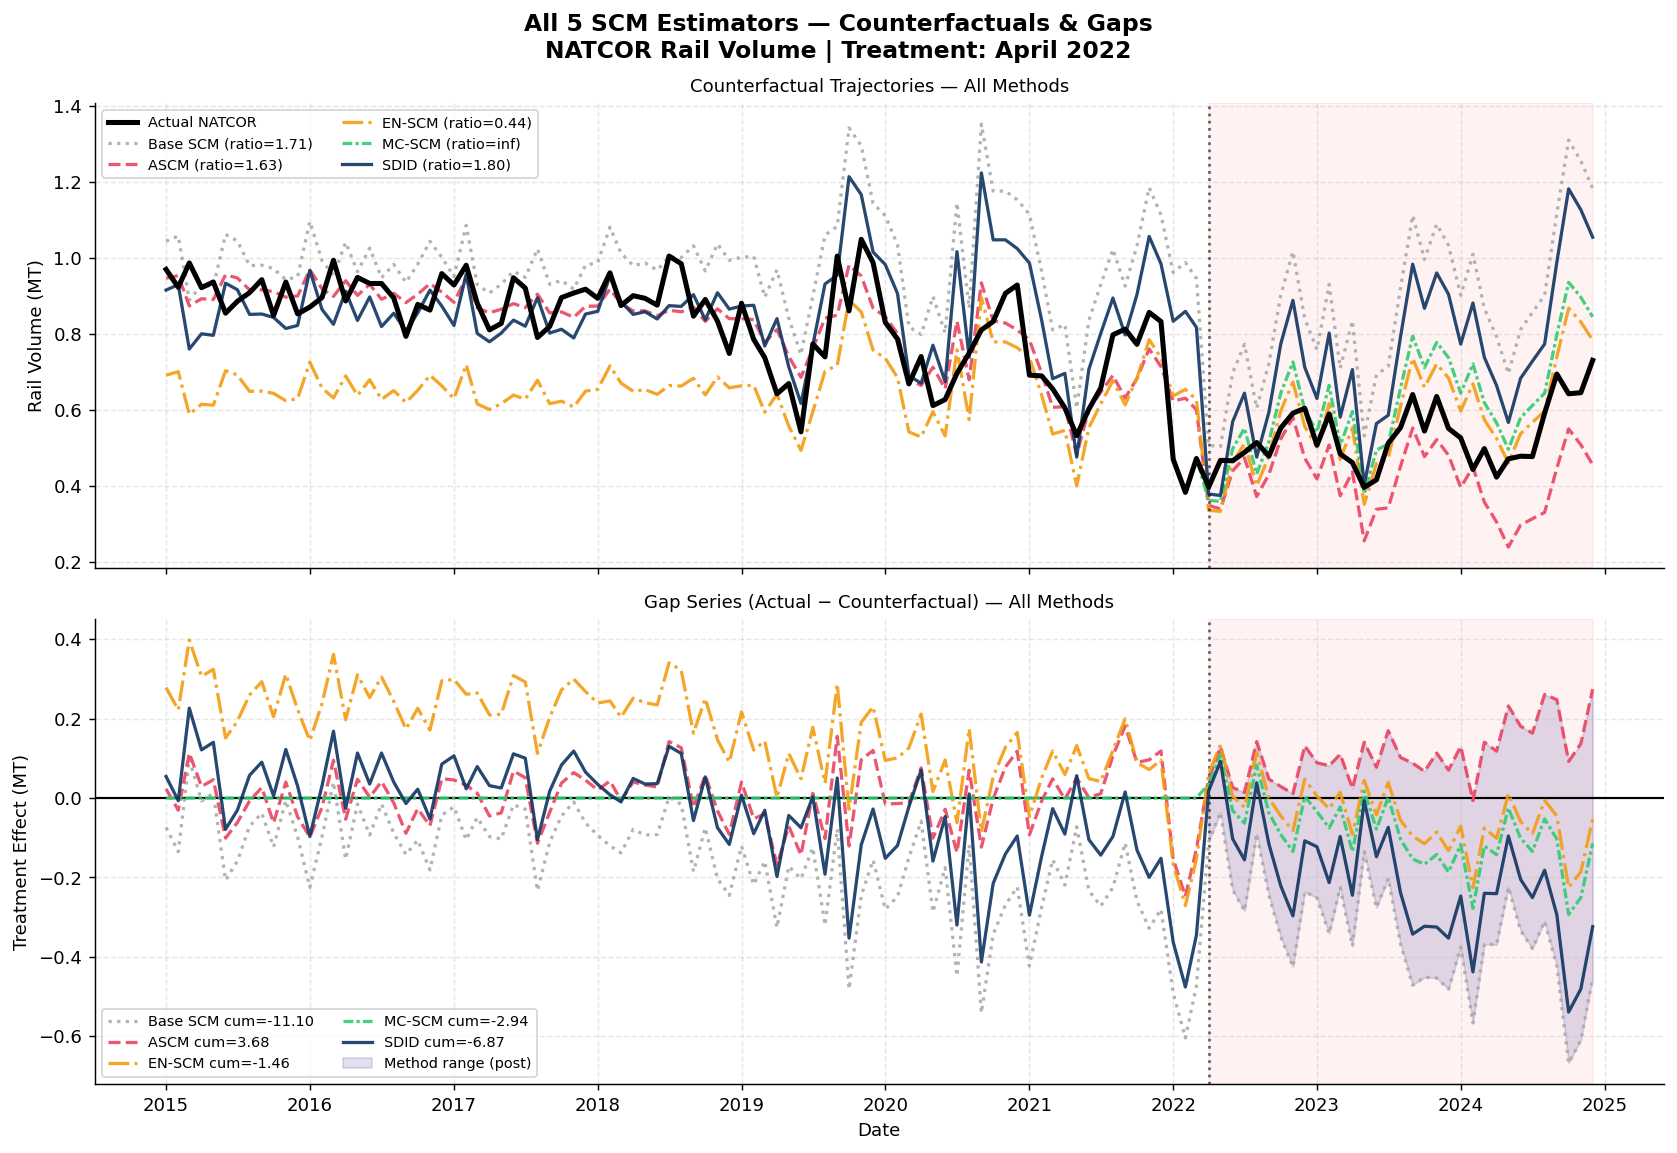

Saved → master_fig1_counterfactuals.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Figure 1: All counterfactuals overlaid
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('All 5 SCM Estimators — Counterfactuals & Gaps\nNATCOR Rail Volume | Treatment: April 2022',
             fontsize=13, fontweight='bold')

# Top: actual + all counterfactuals
ax = axes[0]
ax.plot(t_stamps, Y_all, color='black', lw=2.8, label='Actual NATCOR', zorder=10)
for m in method_order:
    r = results[m]
    ax.plot(t_stamps, r['cf'],
            color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m],
            label=f"{m} (ratio={r['post_r']/r['pre_r']:.2f})", alpha=0.9)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.05, color='red')
ax.set_ylabel('Rail Volume (MT)')
ax.legend(fontsize=8, ncol=2)
ax.set_title('Counterfactual Trajectories — All Methods', fontsize=10)

# Bottom: all gap series
ax = axes[1]
ax.axhline(0, color='black', lw=1.2)
ax.axvline(treat_t, color='black', lw=1.5, ls=':', alpha=0.6)
ax.axvspan(treat_t, t_stamps[-1], alpha=0.05, color='red')

for m in method_order:
    r = results[m]
    ax.plot(t_stamps, r['gap'],
            color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m],
            label=f"{m} cum={r['cum']:.2f}", alpha=0.9)

# Shaded agreement band (min/max across all methods in post-period)
gaps_post = np.array([results[m]['gap'][T_pre:] for m in method_order])
ax.fill_between(t_stamps[T_pre:], gaps_post.min(axis=0), gaps_post.max(axis=0),
                alpha=0.12, color='navy', label='Method range (post)')
ax.set_ylabel('Treatment Effect (MT)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=2)
ax.set_title('Gap Series (Actual − Counterfactual) — All Methods', fontsize=10)

plt.tight_layout()
plt.savefig('master_fig1_counterfactuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_fig1_counterfactuals.png")


## Figure 2 — Ratio, Cumulative Effect & Method Agreement

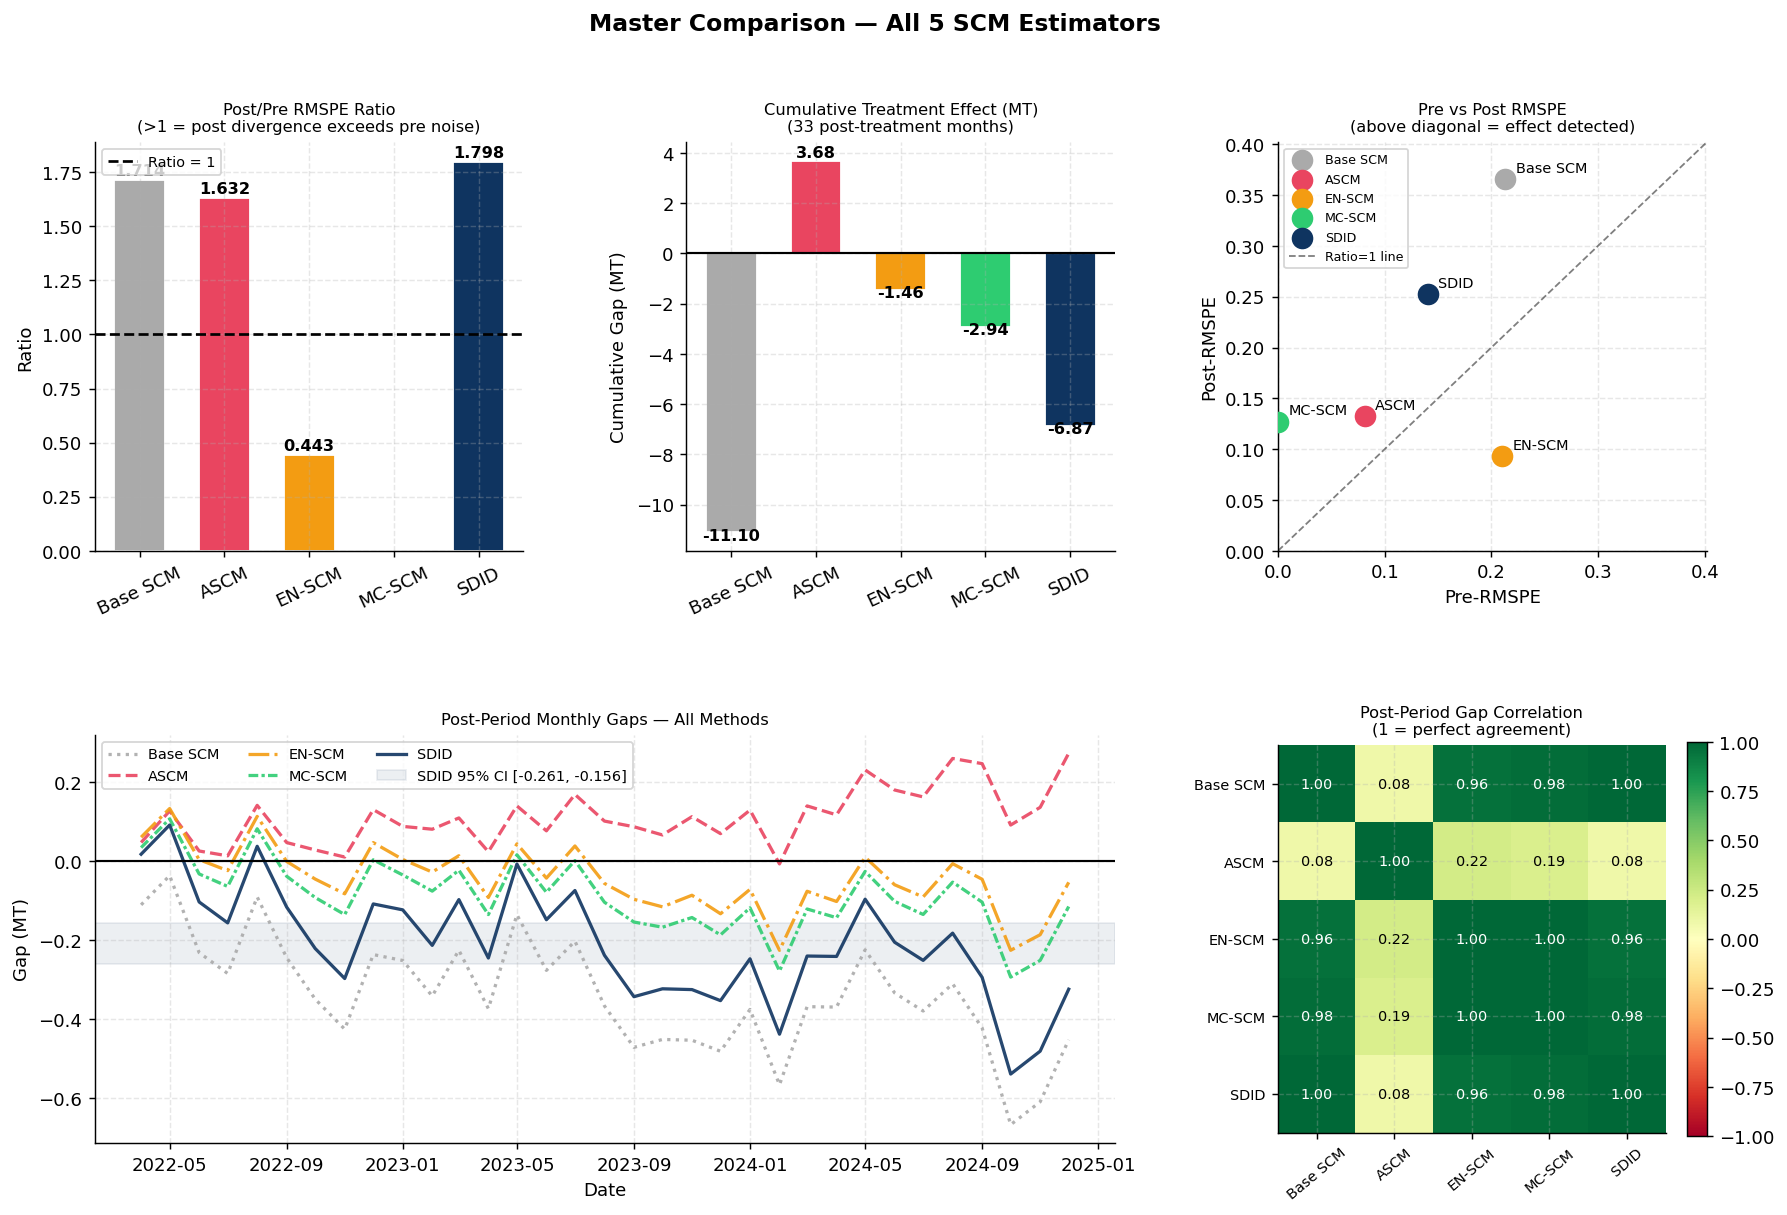

Saved → master_fig2_comparison.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Figure 2: Metric comparison panel
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# ── Plot 1: Post/Pre ratio bar chart ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ratios = [results[m]['post_r']/results[m]['pre_r'] for m in method_order]
bar_c  = [METHOD_COLORS[m] for m in method_order]
bars   = ax1.bar(method_order, ratios, color=bar_c, edgecolor='white', width=0.6)
ax1.axhline(1.0, color='black', lw=1.5, ls='--', label='Ratio = 1')
for bar, val in zip(bars, ratios):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
             ha='center', fontsize=9, fontweight='bold')
ax1.set_title('Post/Pre RMSPE Ratio\n(>1 = post divergence exceeds pre noise)', fontsize=9)
ax1.set_ylabel('Ratio')
ax1.tick_params(axis='x', rotation=25)
ax1.legend(fontsize=8)

# ── Plot 2: Cumulative effect bar chart ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cums = [results[m]['cum'] for m in method_order]
bars2 = ax2.bar(method_order, cums, color=bar_c, edgecolor='white', width=0.6)
ax2.axhline(0, color='black', lw=1.2)
for bar, val in zip(bars2, cums):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (0.15 if val >= 0 else -0.3),
             f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Cumulative Treatment Effect (MT)\n(33 post-treatment months)', fontsize=9)
ax2.set_ylabel('Cumulative Gap (MT)')
ax2.tick_params(axis='x', rotation=25)

# ── Plot 3: Pre vs Post RMSPE scatter ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
pre_rs  = [results[m]['pre_r']  for m in method_order]
post_rs = [results[m]['post_r'] for m in method_order]
for i, m in enumerate(method_order):
    ax3.scatter(pre_rs[i], post_rs[i], color=METHOD_COLORS[m], s=120, zorder=5, label=m)
    ax3.annotate(m, (pre_rs[i], post_rs[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
# 45-degree line (ratio=1)
lim_max = max(max(pre_rs), max(post_rs)) * 1.1
ax3.plot([0, lim_max], [0, lim_max], 'k--', lw=1, alpha=0.5, label='Ratio=1 line')
ax3.set_xlim(0, lim_max); ax3.set_ylim(0, lim_max)
ax3.set_xlabel('Pre-RMSPE'); ax3.set_ylabel('Post-RMSPE')
ax3.set_title('Pre vs Post RMSPE\n(above diagonal = effect detected)', fontsize=9)
ax3.legend(fontsize=7)

# ── Plot 4: Monthly post-period effects — all methods ────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
t_post = t_stamps[T_pre:]
for m in method_order:
    ax4.plot(t_post, results[m]['gap'][T_pre:],
             color=METHOD_COLORS[m], lw=1.8, ls=METHOD_LS[m], label=m, alpha=0.9)
ax4.axhline(0, color='black', lw=1.2)
# SDID CI if available
if 'jk_se' in results['SDID']:
    ci_l = results['SDID']['ci_lo']
    ci_h = results['SDID']['ci_hi']
    ax4.axhspan(ci_l, ci_h, alpha=0.08, color=METHOD_COLORS['SDID'],
                label=f"SDID 95% CI [{ci_l:.3f}, {ci_h:.3f}]")
ax4.set_title('Post-Period Monthly Gaps — All Methods', fontsize=9)
ax4.set_ylabel('Gap (MT)'); ax4.set_xlabel('Date'); ax4.legend(fontsize=8, ncol=3)

# ── Plot 5: Method agreement heatmap ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
n_m = len(method_order)
agree_mat = np.zeros((n_m, n_m))
for i, m1 in enumerate(method_order):
    for j, m2 in enumerate(method_order):
        g1 = results[m1]['gap'][T_pre:]
        g2 = results[m2]['gap'][T_pre:]
        agree_mat[i, j] = np.corrcoef(g1, g2)[0, 1]

im = ax5.imshow(agree_mat, cmap='RdYlGn', vmin=-1, vmax=1)
ax5.set_xticks(range(n_m)); ax5.set_xticklabels(method_order, rotation=40, fontsize=8)
ax5.set_yticks(range(n_m)); ax5.set_yticklabels(method_order, fontsize=8)
for i in range(n_m):
    for j in range(n_m):
        ax5.text(j, i, f'{agree_mat[i,j]:.2f}', ha='center', va='center', fontsize=8,
                 color='black' if abs(agree_mat[i,j]) < 0.8 else 'white')
plt.colorbar(im, ax=ax5, fraction=0.046)
ax5.set_title('Post-Period Gap Correlation\n(1 = perfect agreement)', fontsize=9)

fig.suptitle('Master Comparison — All 5 SCM Estimators', fontsize=13, fontweight='bold')
plt.savefig('master_fig2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_fig2_comparison.png")


## Final Interpretation & Verdict

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Final interpretation
# ═══════════════════════════════════════════════════════════════════════════════

print("═" * 75)
print("MASTER COMPARISON — INTERPRETATION")
print("═" * 75)
print()

ratios = {m: results[m]['post_r']/results[m]['pre_r'] for m in method_order}
cums   = {m: results[m]['cum'] for m in method_order}

print("1. PRE-PERIOD FIT QUALITY")
best_fit = min(method_order, key=lambda m: results[m]['pre_r'])
print(f"   Best pre-RMSPE: {best_fit} ({results[best_fit]['pre_r']:.4f})")
print(f"   Worst pre-RMSPE: {max(method_order, key=lambda m: results[m]['pre_r'])}")
print()

print("2. INFERENCE (Ratio > 1 = effect detected)")
for m in method_order:
    flag = '✓' if ratios[m] > 1 else '✗'
    print(f"   {flag} {m:<12} ratio = {ratios[m]:.4f}")
print()

print("3. EFFECT MAGNITUDE")
for m in method_order:
    extra = ''
    if m == 'SDID' and 'jk_se' in results[m]:
        se = results[m]['jk_se']
        t  = results[m]['t_stat']
        extra = f"  [SE={se:.4f}, t={t:.2f}, {'sig' if abs(t)>1.96 else 'not sig'} at 95%]"
    print(f"   {m:<12}: {cums[m]:+.4f} MT cumulative ({results[m]['avg']:+.4f} MT/month){extra}")
print()

print("4. DIRECTION CONSISTENCY")
signs = [np.sign(cums[m]) for m in method_order]
n_neg = sum(1 for s in signs if s < 0)
n_pos = sum(1 for s in signs if s > 0)
print(f"   Negative (↓ rail volume): {n_neg}/{len(method_order)} methods")
print(f"   Positive (↑ rail volume): {n_pos}/{len(method_order)} methods")
if n_neg == len(method_order) or n_pos == len(method_order):
    print("   → ALL methods agree on direction. Strong robustness signal.")
elif max(n_neg, n_pos) >= 4:
    print(f"   → {max(n_neg,n_pos)}/5 methods agree. Moderate robustness.")
else:
    print("   → Methods disagree on direction. Effect estimate is fragile.")
print()

print("5. SDID FORMAL INFERENCE")
if 'jk_se' in results['SDID']:
    t  = results['SDID']['t_stat']
    cl = results['SDID']['ci_lo'] * T_post
    ch = results['SDID']['ci_hi'] * T_post
    print(f"   ATT = {results['SDID']['avg']:+.4f} MT/month  (t = {t:.3f})")
    print(f"   Jackknife 95% CI (cumulative): [{cl:.3f}, {ch:.3f}] MT")
    print(f"   {'✓ Significant at 95% level' if abs(t)>1.96 else '✗ Not significant at 95% level'}")
print()
print("═" * 75)


═══════════════════════════════════════════════════════════════════════════
MASTER COMPARISON — INTERPRETATION
═══════════════════════════════════════════════════════════════════════════

1. PRE-PERIOD FIT QUALITY
   Best pre-RMSPE: MC-SCM (0.0000)
   Worst pre-RMSPE: Base SCM

2. INFERENCE (Ratio > 1 = effect detected)
   ✓ Base SCM     ratio = 1.7140
   ✓ ASCM         ratio = 1.6320
   ✗ EN-SCM       ratio = 0.4430
   ✓ MC-SCM       ratio = inf
   ✓ SDID         ratio = 1.7980

3. EFFECT MAGNITUDE
   Base SCM    : -11.1040 MT cumulative (-0.3365 MT/month)
   ASCM        : +3.6818 MT cumulative (+0.1116 MT/month)
   EN-SCM      : -1.4575 MT cumulative (-0.0442 MT/month)
   MC-SCM      : -2.9397 MT cumulative (-0.0891 MT/month)
   SDID        : -6.8704 MT cumulative (-0.2082 MT/month)  [SE=0.0267, t=-7.79, sig at 95%]

4. DIRECTION CONSISTENCY
   Negative (↓ rail volume): 4/5 methods
   Positive (↑ rail volume): 1/5 methods
   → 4/5 methods agree. Moderate robustness.

5. SDID FORMAL I